## Optional question:
### Comparing fan votes vs. betting market: which predicts the actual winner more accurately?

#### Fan accuracy:
does the side with MORE fan votes match the real winner? 
#### Market accuracy:
does the side with the LOWEST odds (the bookmakers' favorite) match the real winner?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

IN_DIR = "cleaned_data"

odds = pd.read_parquet(f"{IN_DIR}/odds.parquet")
event = pd.read_parquet(f"{IN_DIR}/event.parquet")[["match_id", "winner_code"]]
votes = pd.read_parquet(f"{IN_DIR}/votes.parquet")
print("Unique market_name values:")
print(odds["market_name"].value_counts())

Unique market_name values:
market_name
full_time             21238
first_set_winner       4080
total_games_won        3696
next_game_winner         22
current_set_winner       22
Name: count, dtype: Int64


### Fan vote accuracy

In [2]:
v = votes.merge(event, on="match_id", how="inner").dropna(subset=["winner_code"])
v = v[(v["home_vote"] + v["away_vote"]) > 0]   # matches with no votes at all can't be judged

v["fans_predicted"] = np.select(
    [v["home_vote"] > v["away_vote"], v["away_vote"] > v["home_vote"]],
    [1, 2],
    default=0,   # a tie in votes -- no real prediction
)
v = v[v["fans_predicted"] != 0]
v["correct"] = v["fans_predicted"] == v["winner_code"]

fan_accuracy = v["correct"].mean() * 100
print(f"Fan vote accuracy: {fan_accuracy:.1f}% (based on {len(v)} matches)")


Fan vote accuracy: 68.3% (based on 13475 matches)


#### Betting market accuracy

In [3]:
match_winner_odds = odds[odds["market_name"] == "full_time"].dropna(subset=["decimal_odds"])

#### For each match, the "favorite" is the choice with the LOWEST decimal odds

In [4]:
favorite_idx = match_winner_odds.groupby("match_id")["decimal_odds"].idxmin()
favorites = match_winner_odds.loc[favorite_idx].dropna(subset=["winning"])

market_accuracy = favorites["winning"].mean() * 100
print(f"Betting market accuracy: {market_accuracy:.1f}% (based on {len(favorites)} matches)")

Betting market accuracy: 67.6% (based on 9477 matches)


#### Fair head-to-head: only matches where BOTH fan votes and market odds exist

In [5]:
common_ids = set(v["match_id"]) & set(favorites["match_id"])
v_common = v[v["match_id"].isin(common_ids)]
fav_common = favorites[favorites["match_id"].isin(common_ids)]

fan_accuracy_common = v_common["correct"].mean() * 100
market_accuracy_common = fav_common["winning"].mean() * 100

print(f"\nHead-to-head on the SAME {len(common_ids)} matches (both fans and market available):")
print(f"  Fans:   {fan_accuracy_common:.1f}%")
print(f"  Market: {market_accuracy_common:.1f}%")


Head-to-head on the SAME 9381 matches (both fans and market available):
  Fans:   68.6%
  Market: 67.7%


# Chart -- side-by-side comparison

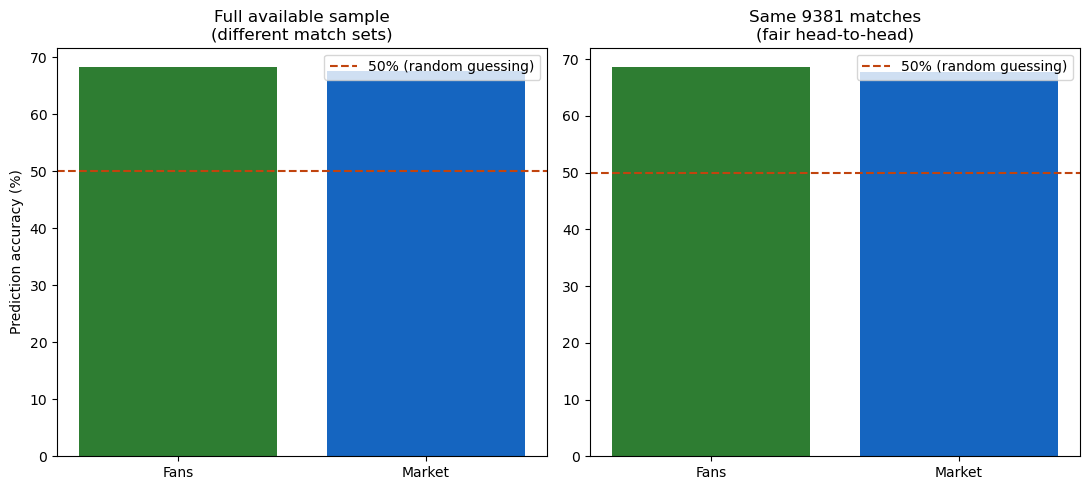

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].bar(["Fans", "Market"], [fan_accuracy, market_accuracy], color=["#2e7d32", "#1565c0"])
axes[0].axhline(50, color="#c1440e", linestyle="--", label="50% (random guessing)")
axes[0].set_title("Full available sample\n(different match sets)")
axes[0].set_ylabel("Prediction accuracy (%)")
axes[0].legend()

axes[1].bar(["Fans", "Market"], [fan_accuracy_common, market_accuracy_common], color=["#2e7d32", "#1565c0"])
axes[1].axhline(50, color="#c1440e", linestyle="--", label="50% (random guessing)")
axes[1].set_title(f"Same {len(common_ids)} matches\n(fair head-to-head)")
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/optional_voteQ_side-by-side comparison.png', dpi=200)
plt.show()

### =======================================================================
### FINDINGS SUMMARY -- Fan votes vs. betting market prediction accuracy
### =======================================================================

### Question: Comparing fan votes and the betting market -- which predicts the actual match winner more accurately?

## Results:
  Full available samples (different match sets):
    Fan vote accuracy:      68.3% (n=13,475 matches)
    Betting market accuracy: 67.6% (n=9,477 matches)

  Fair head-to-head (same 9,381 matches, both sources available):
    Fan vote accuracy:       68.6%
    Betting market accuracy: 67.7%

## Interpretation:
Both prediction sources performed far above the 50% random-guessing baseline (~18 percentage points higher), showing that both fan opinion and betting markets carry real predictive information about match outcomes.

The gap between the two is very small (0.9 percentage points in the fair head-to-head comparison) -- likely within statistical noise given the sample size, rather than a clearly meaningful advantage for either side. In other words, fans and the betting market performed roughly equally well at predicting winners in this dataset.

## This is a somewhat counter-intuitive finding:
betting markets are often assumed to outperform crowd opinion because real money is at stake. A plausible explanation here is that this dataset is dominated by lower-tier tournaments (ITF/Challenger, not top ATP/WTA events), where neither the betting market nor fans likely have access to much deeper analysis than the other -- narrowing the usual gap between "informed" market pricing and casual fan sentiment.

## Methodology note:
matches where votes/odds were tied, missing, or had no market data were excluded from the relevant accuracy calculation, so both percentages reflect only the subset of matches where a clear prediction could be made.
